<a href="https://colab.research.google.com/github/Sarasii22/Sleep-Quality-Prediction-Using-Lifestyle-Factors/blob/main/Data_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Sleep Quality Prediction using Lifestyle Factors

This notebook implements a machine learning project to predict 'Quality of Sleep' using various lifestyle factors. We will use Logistic Regression and K-Nearest Neighbors (KNN) algorithms for this multi-class classification task.

### 1. Data Loading and Initial Exploration

In [ ]:
import pandas as pd
import numpy as np
#import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import LabelEncoder, StandardScaler
# from sklearn.linear_model import LogisticRegression
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# Mount Google Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive')

# Load the dataset
data = pd.read_csv("/content/drive/MyDrive/ML_project/Sleep_health_and_lifestyle_dataset.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [ ]:
data.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [ ]:
data.isnull().sum()

,0
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Blood Pressure,0


### 2. Data Cleaning and Preprocessing

In [ ]:
data = data.drop(['Person ID'], axis=1)
print("DataFrame after dropping 'Person ID':")
data.head()

DataFrame after dropping 'Person ID':


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [ ]:
# Split 'Blood Pressure' into 'Systolic' and 'Diastolic'
data[['Systolic', 'Diastolic']] = data['Blood Pressure'].str.split('/', expand=True)

In [ ]:
# Convert 'Systolic' and 'Diastolic' to integer type
data['Systolic'] = data['Systolic'].astype(int)
data['Diastolic'] = data['Diastolic'].astype(int)

In [ ]:
# Drop the original 'Blood Pressure' column
data = data.drop('Blood Pressure', axis=1)
print("\nDataFrame after processing 'Blood Pressure':")
data.head()


DataFrame after processing 'Blood Pressure':


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,NaN,126,83
1,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125,80
2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125,80
3,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90


In [ ]:
# Label Encode 'Gender'
le = LabelEncoder()
data['Gender'] = le.fit_transform(data['Gender'])
print("\nDataFrame after Label Encoding 'Gender':")
display(data.head())


DataFrame after Label Encoding 'Gender':


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,1,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,NaN,126,83
1,1,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125,80
2,1,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125,80
3,1,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,1,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90


In [ ]:
# Perform one-hot encoding for 'Occupation' and 'BMI Category'
data = pd.get_dummies(data, columns=['Occupation', 'BMI Category'], drop_first=False, dtype=int)

print("DataFrame after One-Hot Encoding 'Occupation' and 'BMI Category':")
display(data.head())
print("\nUpdated DataFrame shape:", data.shape)

DataFrame after One-Hot Encoding 'Occupation' and 'BMI Category':


,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Sleep Disorder,Systolic,...,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Normal,BMI Category_Normal Weight,BMI Category_Obese,BMI Category_Overweight
0,1,27,6.1,6,42,6,77,4200,NaN,126,...,0,0,0,0,1,0,0,0,0,1
1,1,28,6.2,6,60,8,75,10000,NaN,125,...,0,0,0,0,0,0,1,0,0,0
2,1,28,6.2,6,60,8,75,10000,NaN,125,...,0,0,0,0,0,0,1,0,0,0
3,1,28,5.9,4,30,8,85,3000,Sleep Apnea,140,...,0,1,0,0,0,0,0,0,1,0
4,1,28,5.9,4,30,8,85,3000,Sleep Apnea,140,...,0,1,0,0,0,0,0,0,1,0



Updated DataFrame shape: (374, 26)


### 3. Feature and Target Variable Split

In [ ]:
# Define features (X) and new target (y)
# Drop 'Quality of Sleep' as per user request ('not sleep quality')
# Drop original 'Sleep Disorder' and the new target 'has_sleep_disorder' from features
X = data.drop(['Quality of Sleep', 'Sleep Disorder', 'has_sleep_disorder'], axis=1)
y = data['has_sleep_disorder']

print("Features (X) head:")
display(X.head())
print("\nTarget (y) head:")
display(y.head())
print("\nValue counts for new target (y):")
display(y.value_counts())

Features (X) head:


,Gender,Age,Occupation,Sleep Duration,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Systolic,Diastolic
0,1,27,9,6.1,42,6,3,77,4200,126,83
1,1,28,1,6.2,60,8,0,75,10000,125,80
2,1,28,1,6.2,60,8,0,75,10000,125,80
3,1,28,6,5.9,30,8,2,85,3000,140,90
4,1,28,6,5.9,30,8,2,85,3000,140,90



Target (y) head:


,has_sleep_disorder
0,0
1,0
2,0
3,1
4,1



Value counts for new target (y):


,count
has_sleep_disorder,
0,219
1,155


### 4. Train-Test Split and Feature Scaling

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # Stratify to maintain class distribution

# Initialize StandardScaler and scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)

# Check the distribution of y_train and y_test to ensure stratification worked
print("\nDistribution of 'has_sleep_disorder' in y_train:")
display(y_train.value_counts(normalize=True).sort_index())
print("\nDistribution of 'has_sleep_disorder' in y_test:")
display(y_test.value_counts(normalize=True).sort_index())

Shape of X_train_scaled: (299, 11)
Shape of X_test_scaled: (75, 11)

Distribution of 'has_sleep_disorder' in y_train:


,proportion
has_sleep_disorder,
0,0.585284
1,0.414716



Distribution of 'has_sleep_disorder' in y_test:


,proportion
has_sleep_disorder,
0,0.586667
1,0.413333


### 5. Model Training and Evaluation - Logistic Regression

Logistic Regression Model Evaluation:
Accuracy: 0.9200

Classification Report:
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         1
           5       0.00      0.00      0.00         1
           6       0.83      0.95      0.89        21
           7       0.93      0.81      0.87        16
           8       1.00      1.00      1.00        22
           9       1.00      1.00      1.00        14

    accuracy                           0.92        75
   macro avg       0.63      0.63      0.63        75
weighted avg       0.91      0.92      0.91        75



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


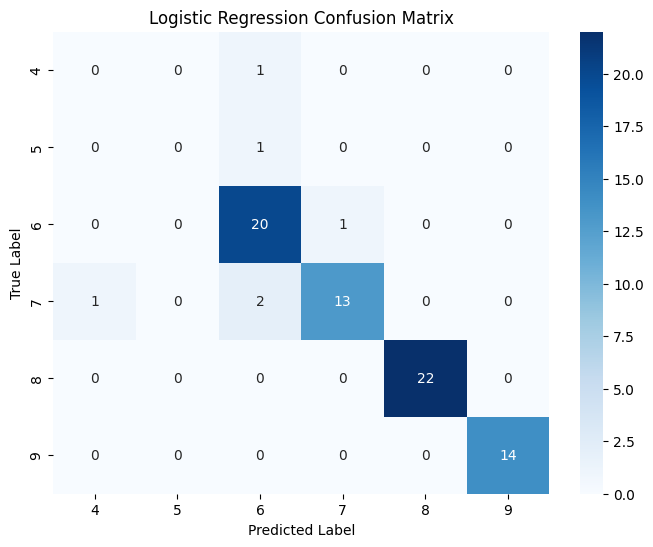

In [ ]:
# Initialize and train the Logistic Regression model
# Increased max_iter for convergence, added solver 'liblinear' for multi-class with L1/L2 regularization
log_reg_model = LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')
log_reg_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_log_reg = log_reg_model.predict(X_test_scaled)

# Evaluate the model
print("Logistic Regression Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log_reg))

# Confusion Matrix
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_log_reg, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.sort(y.unique()), yticklabels=np.sort(y.unique())) # Use sorted unique values for labels
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

### 6. Model Training and Evaluation - K-Nearest Neighbors (KNN)

K-Nearest Neighbors Model Evaluation:
Accuracy: 0.8933

Classification Report:
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         1
           5       0.00      0.00      0.00         1
           6       0.83      0.95      0.89        21
           7       0.87      0.81      0.84        16
           8       1.00      0.95      0.98        22
           9       1.00      0.93      0.96        14

    accuracy                           0.89        75
   macro avg       0.62      0.61      0.61        75
weighted avg       0.90      0.89      0.89        75



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


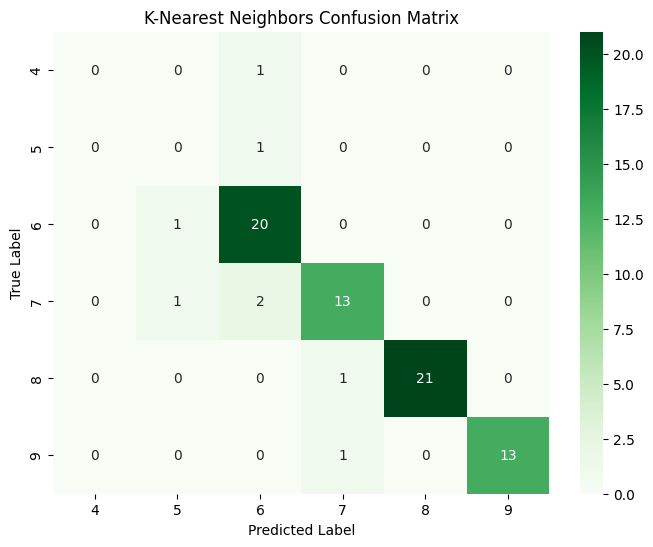

In [ ]:
# Initialize and train the KNN model
# You can experiment with different values for n_neighbors, a common starting point is 5
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_knn = knn_model.predict(X_test_scaled)

# Evaluate the model
print("K-Nearest Neighbors Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

# Confusion Matrix
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Greens',
            xticklabels=np.sort(y.unique()), yticklabels=np.sort(y.unique())) # Use sorted unique values for labels
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('K-Nearest Neighbors Confusion Matrix')
plt.show()

### 7. Model Comparison and Conclusion

In [ ]:
from tabulate import tabulate

# Collect accuracy scores
log_reg_accuracy = accuracy_score(y_test, y_pred_log_reg)
knn_accuracy = accuracy_score(y_test, y_pred_knn)

# Prepare data for comparison table
comparison_data = [
    ["Logistic Regression", f"{log_reg_accuracy:.4f}"],
    ["K-Nearest Neighbors", f"{knn_accuracy:.4f}"]
]

headers = ["Model", "Accuracy"]

print("\n--- Model Performance Comparison ---")
print(tabulate(comparison_data, headers=headers, tablefmt='grid'))

print("\n--- Conclusion ---")
if log_reg_accuracy > knn_accuracy:
    print(f"The Logistic Regression model performed slightly better with an accuracy of {log_reg_accuracy:.4f}.")
    print("This suggests that for this dataset, a linear decision boundary might be more effective or that the chosen `n_neighbors` for KNN was not optimal. Consider further hyperparameter tuning for both models.")
elif knn_accuracy > log_reg_accuracy:
    print(f"The K-Nearest Neighbors model performed slightly better with an accuracy of {knn_accuracy:.4f}.")
    print("This suggests that the local neighborhood structure is important for classification. Consider further hyperparameter tuning for both models, especially the `n_neighbors` for KNN.")
else:
    print(f"Both Logistic Regression and K-Nearest Neighbors models performed similarly with an accuracy of {log_reg_accuracy:.4f}.")
    print("Further investigation, such as hyperparameter tuning and analyzing other metrics like precision and recall per class, might reveal more insights into their subtle differences.")

print("\n--- Next Steps and Considerations ---")
print("1. **Hyperparameter Tuning:** Use `GridSearchCV` or `RandomizedSearchCV` for both Logistic Regression (e.g., regularization strength C) and KNN (e.g., `n_neighbors`, `weights`, `metric`) to find optimal model configurations.")
print("2. **Cross-Validation:** Implement k-fold cross-validation during tuning and final evaluation to get a more robust estimate of model performance and reduce variance.")
print("3. **Addressing Class Imbalance:** Given the distribution of 'Quality of Sleep' scores (as observed in initial `y_train` balance check), classes with fewer samples might be difficult to predict. Techniques like SMOTE (Synthetic Minority Over-sampling Technique) or adjusting class weights in Logistic Regression could be beneficial.")
print("4. **Feature Importance Analysis:** For Logistic Regression, you can analyze the coefficients to understand which features contribute most to the prediction of sleep quality scores. This can provide valuable insights into lifestyle factors.")
print("5. **Ordinal Nature of Target:** 'Quality of Sleep' is an ordinal variable (ordered categories). While standard classification algorithms treat it as nominal, exploring specific ordinal regression models could potentially yield better results if the ordering information is crucial.")
print("6. **Error Analysis:** Analyze the confusion matrices to identify which specific sleep quality scores are being confused by the models. This can guide further feature engineering or model selection.")


--- Model Performance Comparison ---
+---------------------+------------+
| Model               |   Accuracy |
+=====================+============+
| Logistic Regression |     0.92   |
+---------------------+------------+
| K-Nearest Neighbors |     0.8933 |
+---------------------+------------+

--- Conclusion ---
The Logistic Regression model performed slightly better with an accuracy of 0.9200.
This suggests that for this dataset, a linear decision boundary might be more effective or that the chosen `n_neighbors` for KNN was not optimal. Consider further hyperparameter tuning for both models.

--- Next Steps and Considerations ---
1. **Hyperparameter Tuning:** Use `GridSearchCV` or `RandomizedSearchCV` for both Logistic Regression (e.g., regularization strength C) and KNN (e.g., `n_neighbors`, `weights`, `metric`) to find optimal model configurations.
2. **Cross-Validation:** Implement k-fold cross-validation during tuning and final evaluation to get a more robust estimate of model 